In [11]:
from itertools import product
from qiskit import *
from qiskit.visualization import *
from qiskit.circuit.library import *
import math
import numpy as np
import networkx as nx
import pandas as pd

from qiskit_aer.primitives import Sampler as Aer_Sampler
from qiskit_aer import AerSimulator
# from qiskit.primitives import BackendSamplerV2 as Sampler
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

np.set_printoptions(precision=3, suppress=True, threshold=50000, linewidth=5000)

import warnings

warnings.simplefilter("ignore")
import json
import plotly.express as px
import plotly.graph_objects as go
from scipy.interpolate import griddata


In [ ]:
def print_matrix(matrix):
    """
    Prints a matrix in a readable comma-separated format.
    
    Args:
        matrix (list of lists): The matrix to print.
    """
    msg = ""
    for row in matrix:
        line = ""
        for c in row:
            line += f"{c}, "
        msg += f"{line}\n"
    print(msg)
    
def strategy_gate(theta, phi, player, lamda=0):
    """
    Creates a unitary gate representing a quantum strategy for a player in the Prisoner's Dilemma.
    
    Args:
        theta (float): Angle controlling cooperation/defection (0: cooperate, pi: defect).
        phi (float): Phase parameter for the strategy.
        player (str): Label for the player.
        lamda (float, optional): Additional phase parameter (default 0 for standard strategy).
    
    Returns:
        UnitaryGate: The quantum gate for the strategy.
    """
    strategy_matrix = [
        [math.cos(theta/2), -1 * math.e**(1j*lamda) * math.sin(theta/2)],
        [math.e**(1j*phi) * math.sin(theta/2), math.e**(1j*  (phi + lamda)) * math.cos(theta/2)]
    ]
        
    strategy_gate = UnitaryGate(strategy_matrix, label=f"U {player}")
    return strategy_gate

def payoff_vals(num_players):
    """
    Function to calculate the payoff values for cooperation and defection
    Arbitraliry chosen payoff function parameters for easier comprehension.
    
    ---
    Inputs:
        (int) num_players: Number of players in the game
    
    Outputs:
        (list): list of payoff values for cooperation
        (list): list of payoff values for defection
    """
    return [2*i for i in range(1, num_players+1)], [2*i + 1 for i in range(1, num_players+1)]

def get_payoff_matrix():
    """
    Function to calculate the payoff matrix for all possible states.
    Calculates the payoff using the values for payoff_vals() function and
    assigns them based on the number of Cooperation moves in each state.
    
    ---
    Inputs:
        (int): Number of players in the game
        
    Ouputs:
        (list): Payoff matrix in list of lists form with shape n x 2**n
        
    """
    num_players = 2
    coop_payoffs, defect_payoffs = [5, 1], [3, 0]
    payoff_matrix = [[0 for _ in range(num_players)] for _ in range(2**num_players)]

    actions = list(product(['0', '1'], repeat=num_players))

    for i in range(len(actions)):
        P = actions[i].count('0')
        for j in range(num_players):
            if actions[i][j] == '0':
                payoff_matrix[i][j] = coop_payoffs[P-1]
            else:
                payoff_matrix[i][j] = defect_payoffs[P]

    action_payoffs = {}
    for i, action in enumerate(actions):
        action_payoffs[action[0]+action[1]] = payoff_matrix[i]

    return action_payoffs

def get_results(logfile):
    """
    Processes results from the given logfile and computes average payoffs per player.
    
    Args:
        logfile (str): Path to the CSV logfile.
    
    Returns:
        pandas.Series: Mean payoffs for each player across games.
    """
    df = pd.read_csv(logfile, delimiter="|")
    df["round"] = [game_id % 4 for game_id in df["game_id"]]
    for player in range(4):

        df[f"player{player}_payoffs"] = ["".join(row) for row in df[f"player{player}_payoffs"]]
        df[f"player{player}_payoffs"] = [json.loads(row) for row in df[f"player{player}_payoffs"]]    
        df[f"p{player}_avg"] = [np.mean(l) for l in df[f"player{player}_payoffs"]]


    df_group = df[['p0_avg','p1_avg','p2_avg','p3_avg']].mean()
    return df_group


In [ ]:
def run_exp(quantum_player, knowledge_sharing, adj_matrix, logfile, mode="simulated", overwrite=True):
    """
    Runs the quantum prisoner's dilemma experiment for multiple players with one quantum player.
    
    Args:
        quantum_player (int): Index of the player using a quantum strategy.
        knowledge_sharing (bool): Whether to enable knowledge sharing between games.
        adj_matrix (numpy.ndarray): Adjacency matrix representing player connections.
        logfile (str): Path to the output logfile.
        mode (str, optional): "simulated" for AerSimulator or "qpu" for real quantum hardware (default "simulated").
        overwrite (bool, optional): Whether to overwrite the logfile (default True).
    
    Returns:
        QuantumCircuit: The constructed quantum circuit.
    """

    if mode == "qpu":
        service = QiskitRuntimeService(channel="ibm_quantum_platform", token="iDfGDezY0xsV7eBEnhRU0AQppWmXkAJAmNlGmBg6BU3_")
        backend = service.backend("ibm_torino")
    
    theta = math.pi/2
    phi = 0
    lamda = 0
    num_players = len(adj_matrix)

    strategies = {}
    for player in range(num_players):
        strategies[player] = {
                "gate": strategy_gate(theta=0, phi=0, lamda=0, player=f"p{player}"),
                "theta": 0,
                "phi": 0,
                "lamda": 0,
                "quantum": False
        }

    strategies[quantum_player] = {
            "gate": strategy_gate(theta=theta, phi=phi, lamda=lamda, player=f"q{quantum_player}"),
            "theta": 0,
            "phi": math.pi/2,
            "lamda": 0,
            "quantum": True
        }

    for game_id in range(2):

        G = nx.from_numpy_matrix(adj_matrix)

        num_games = len(G.edges)
        games = {}
        game = 0
        for edge in G.edges:
            games[game] = edge
            game += 1

        qubits_per_player = {k: [] for k in range(G.number_of_nodes())}
        qubit = 0
        for game in games:
            qubits_per_player[games[game][0]].append(qubit)
            qubit += 1
            qubits_per_player[games[game][1]].append(qubit)
            qubit += 1


        knowledge_pairs = {k: [] for k in range(G.number_of_nodes())}
        for player in qubits_per_player:
            for i in range(len(qubits_per_player[player])-1):
                knowledge_pairs[player].append((qubits_per_player[player][i], qubits_per_player[player][i+1]))

        circuit = QuantumCircuit(2*len(G.edges()))
        q1 = 0
        q2 = 1
        for game in games:
            # Knowledge passing from player to new game
            p1 = games[game][0]
            p2 = games[game][1]

            # Quantum Prisoner's Dilemma with standard entaglement, quantum strategy
            circuit.h(q1)
            circuit.cx(q1,q2)
            circuit.append(strategies[p1]["gate"], [q1])
            circuit.append(strategies[p2]["gate"], [q2])
            circuit.cx(q1,q2)
            circuit.h(q1)

            circuit.barrier() 

            # Knowledge Sharing
            if knowledge_sharing:
                try:
                    circuit.cx(knowledge_pairs[p1][0][0], knowledge_pairs[p1][0][1])
                    knowledge_pairs[p1].pop(0)
                except Exception as e:
                    pass

                try:
                    circuit.cx(knowledge_pairs[p2][0][0], knowledge_pairs[p2][0][1])
                    knowledge_pairs[p2].pop(0)
                except Exception as e:
                    pass

                circuit.barrier()

        #   New game set
            q1 += 2
            q2 += 2

        circuit.measure_all()
        
        if mode == "simulated":
            backend = AerSimulator(shots=1000)
            d = Aer_Sampler().run([circuit], shots=1000).result().quasi_dists[0]
        elif mode == "qpu":
            sampler = Sampler(mode=backend)

            transpiled_circuit = transpile(circuit, backend)
            pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
            transpiled_circuit = pass_manager.run(circuit)

            # Run the circuit on the selected QPU
            job = sampler.run([(transpiled_circuit, {})]) # { } is for parameter values

            result = job.result()
            d = result[0].data.meas.get_counts()

        game_end_state = max(d, key=d.get)
        if mode == "simulated":
            game_end_state = "{0:b}".format(int(game_end_state))
            game_end_state = str(game_end_state).rjust(2*num_games, "0")

        schema = "game_result|game_id|round|game|player|is_quantum|payoff\n"
    
        action_payoffs = get_payoff_matrix()
        chunks, chunk_size = len(game_end_state), int(len(game_end_state)//(len(game_end_state)/2))
        game_results = [game_end_state[i:i+chunk_size] for i in range(0, chunks, chunk_size)]
        player_payoffs = {}
        for game in games:
            for i, player in enumerate(games[game]):
                if player not in player_payoffs:
                    player_payoffs[player] = [action_payoffs[game_results[game]][i]]
                else:
                    player_payoffs[player].append(action_payoffs[game_results[game]][i])

        msg=""
        for player in strategies:
            for game_round in range(2):
                msg += f"""{str(game_end_state).rjust(8, "0")}|{game_id}|{game_round}|{str(games)}|{player}|{player == quantum_player}|{player_payoffs[player][game_round]}\n"""
                
        try:
            with open(logfile, "a+") as file:
                file.write(f"{msg[:-1]}\n")
        except:
            print(msg)

    return circuit


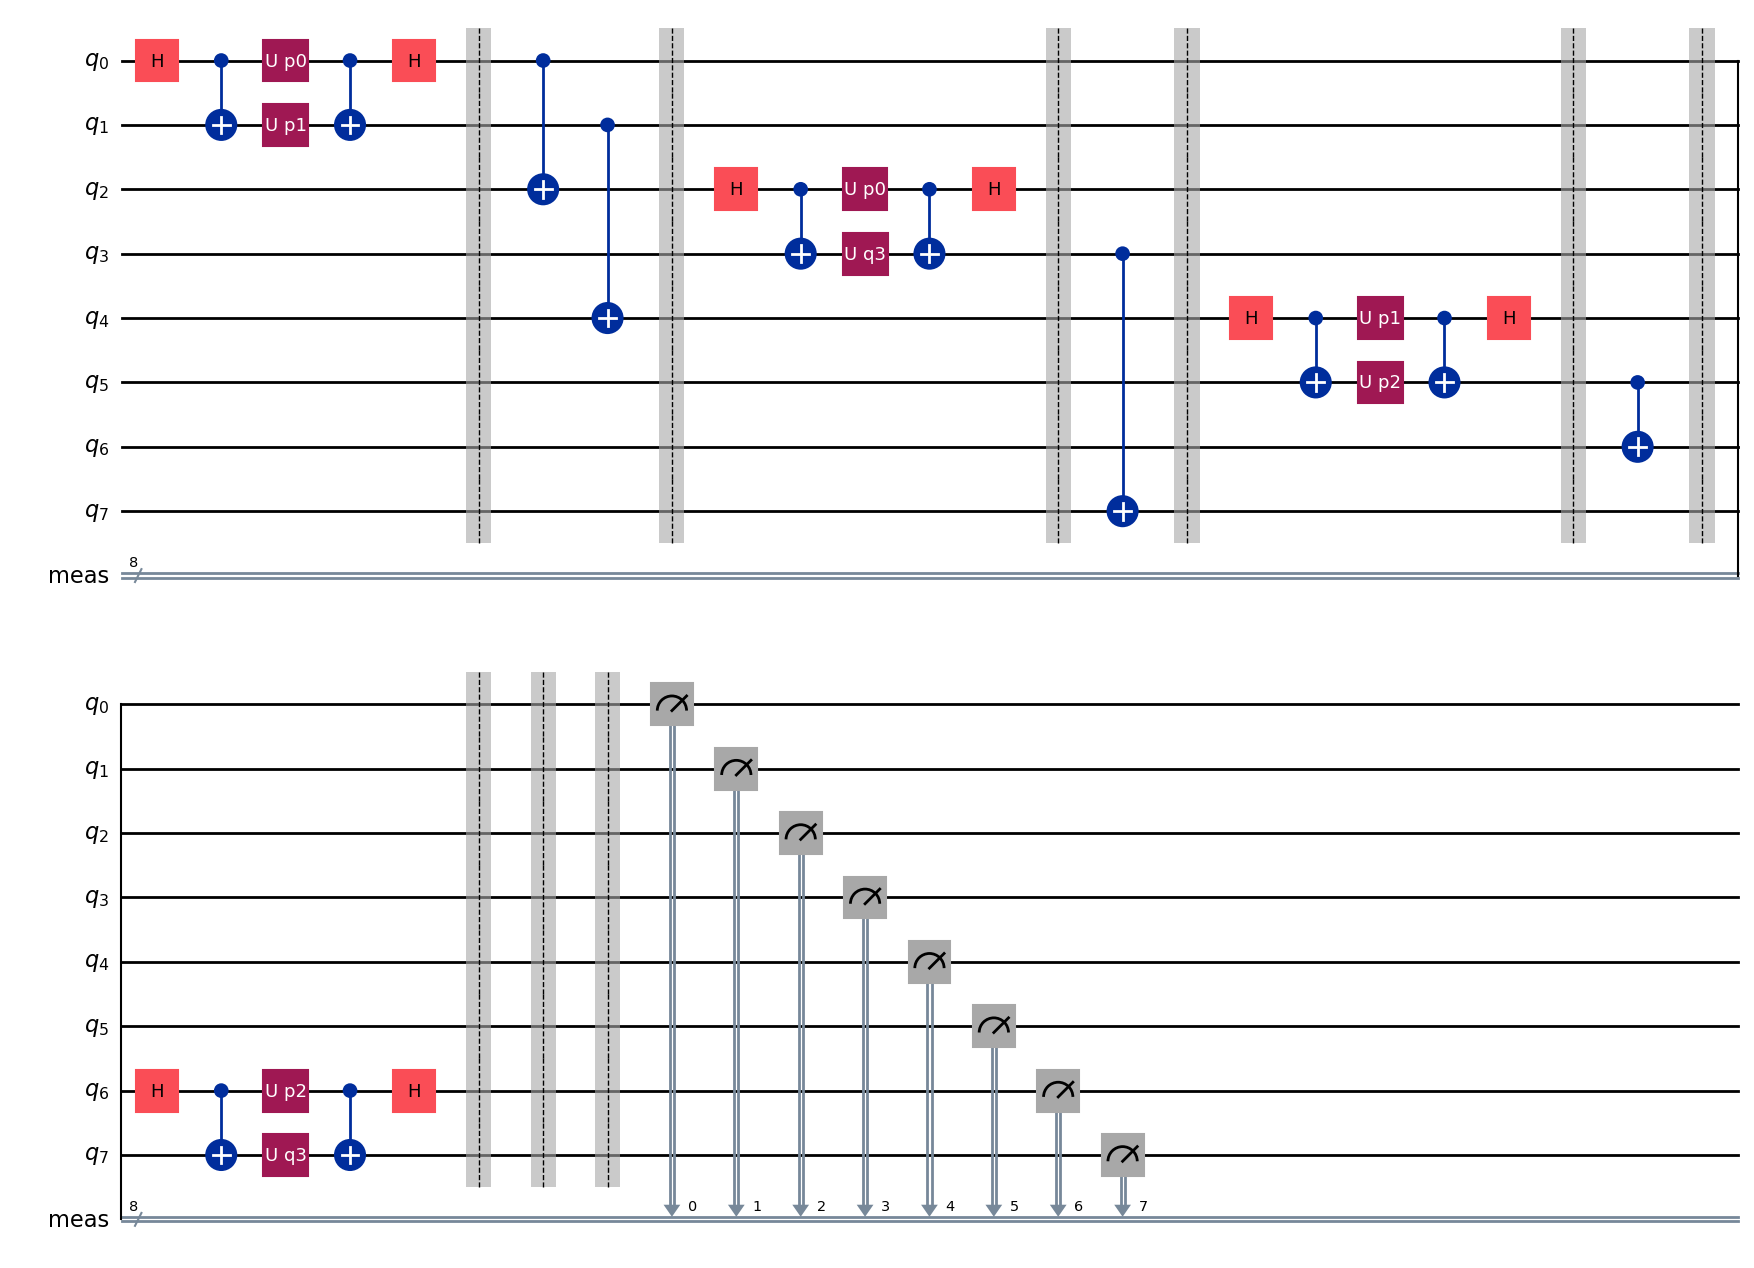

In [ ]:
if __name__ == "__main__":
    knowledge_sharing = True
    # quantum_player = 0

    adj_matrix = np.array(
        [
            [0, 1, 0, 1],
            [1, 0, 1, 0],
            [0, 1, 0, 1],
            [1, 0, 1, 0]
        ]
    )
    logfile = "data/results.csv"
    schema = "game_result|game_id|round|game|player|is_quantum|payoff\n"

    with open(logfile, "w+") as file:
        file.write(schema)

    for quantum_player in range(4):
        circ = run_exp(quantum_player, knowledge_sharing, adj_matrix, logfile, "simulated",False)
    circ.draw(output="mpl")